<a href="https://colab.research.google.com/github/siwarTaha/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Prediction of Product Sales

Siwar Ehwass

## Project Overview

### Data Dictionary

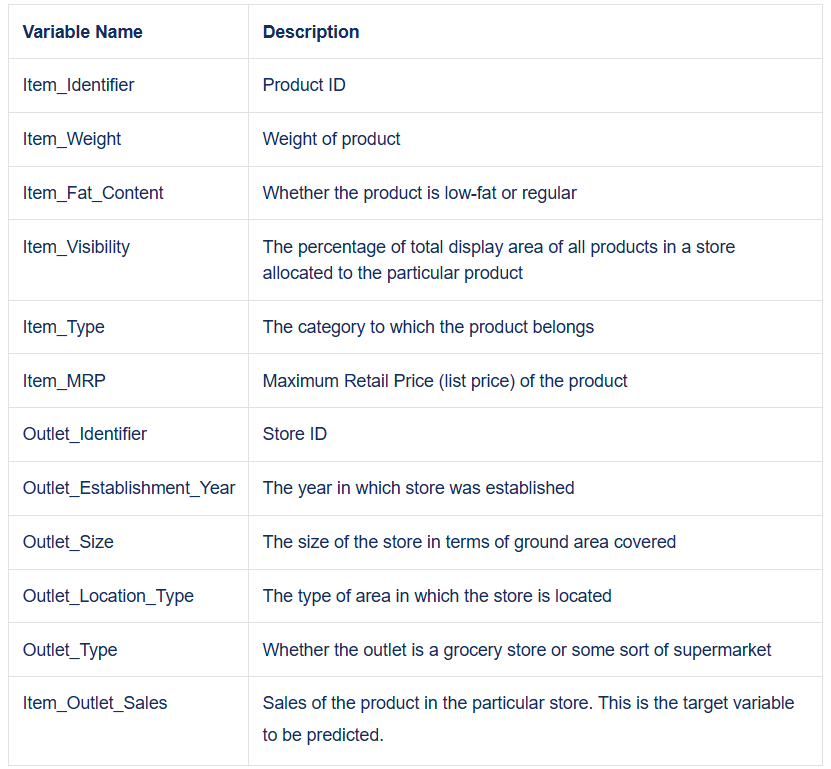

## Load and Inspect Data

### Imports

In [1]:
import pandas as pd
import missingno as msno

### Loading Data

In [2]:
path='https://docs.google.com/spreadsheets/d/e/2PACX-1vR6AvAZumX2EE8diEPYfNdktYpa8cELog1Iv_SL7EIFj_DIVxnGwq5liujvJ1GTQry9NDkFsISbeWaE/pub?output=csv'
df=pd.read_csv(path)

In [ ]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Clean Data

### Rename Columns

In [3]:
# rename columns
rename_dict={'Item_Identifier':'Product id',
             'Item_Weight':'Weight',
             'Item_Fat_Content':'Fat Content',
             'Item_Visibility':'Visibility',
             'Item_Type':'Category',
             'Item_MRP':'Product MRP',
             'Outlet_Identifier':'Store id',
             'Outlet_Establishment_Year':'Year Established',
             'Outlet_Size':'Store size',
             'Outlet_Location_Type':'Area',
             'Outlet_Type':'Store type'}

In [4]:
# apply the changes to the dataframe
df=df.rename(rename_dict,axis=1)
df.head()

,Product id,Weight,Fat Content,Visibility,Category,Product MRP,Store id,Year Established,Store size,Area,Store type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


### Check Data Types, Fix, and Convert
- Fixing Outlet ID from a string to an integer

In [6]:
# view object columns
cat_cols=df.select_dtypes('object').columns
df[cat_cols].head()

,Product id,Fat Content,Category,Store id,Store size,Area,Store type
0,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 1,Supermarket Type1
1,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 3,Supermarket Type2
2,FDN15,Low Fat,Meat,OUT049,Medium,Tier 1,Supermarket Type1
3,FDX07,Regular,Fruits and Vegetables,OUT010,NaN,Tier 3,Grocery Store
4,NCD19,Low Fat,Household,OUT013,High,Tier 3,Supermarket Type1


- One categorical columns should be numbers:
  - Store id

To change it, we view value counts for the column to see what to replace:

In [7]:
# check value counts for Store id
df['Store id'].value_counts()

,count
Store id,
OUT027,935
OUT013,932
OUT035,930
OUT049,930
OUT046,930
OUT045,929
OUT018,928
OUT017,926
OUT010,555


In [8]:
# fix outlet identifier data type into integer
df['Store id']=df['Store id'].str.replace('OUT','')
df['Store id']=df['Store id'].astype(int)
df['Store id'].dtypes

dtype('int64')

### Duplicated Rows

In [13]:
# check for duplicated data
duplicated_rows=df.duplicated()
duplicated_rows.sum()

np.int64(0)

- there are no duplicated values



### Unique Identifiers

In [14]:
# number of unique values for each column
df.nunique()

,0
Product id,1559
Weight,415
Fat Content,5
Visibility,7880
Category,16
Product MRP,5938
Store id,10
Year Established,9
Store size,3
Area,3


In [23]:
# percentage of unique values in each columns
df.nunique() / len(df) * 100

,0
Product id,18.291681
Weight,4.869178
Fat Content,0.058665
Visibility,92.455708
Category,0.187727
Product MRP,69.670304
Store id,0.117330
Year Established,0.105597
Store size,0.035199
Area,0.035199


In [24]:
# how many rows are duplicates when product id and store id identify as unique values
duplicated_id=df.duplicated(subset=['Product id', 'Store id'],keep=False)
duplicated_id.sum()

np.int64(0)

- there are no duplicated values in the data set.

### Missing Values
- Checking for NaN rows:

In [25]:
# see columns and rows where NaN is present
df.isna()

,Product id,Weight,Fat Content,Visibility,Category,Product MRP,Store id,Year Established,Store size,Area,Store type,Item_Outlet_Sales
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,False,False,False,False,False,False,False,False,False,False,False,False
8519,False,False,False,False,False,False,False,False,True,False,False,False
8520,False,False,False,False,False,False,False,False,False,False,False,False
8521,False,False,False,False,False,False,False,False,False,False,False,False


In [26]:
# check how many rows in each column has a missing value
null_sums=df.isna().sum()
null_sums

,0
Product id,0
Weight,1463
Fat Content,0
Visibility,0
Category,0
Product MRP,0
Store id,0
Year Established,0
Store size,2410
Area,0


In [27]:
# check the percentage of null values
null_percent=null_sums/len(df)*100
null_percent[null_percent>0]

,0
Weight,17.165317
Store size,28.276428


- 17.16% from Weight column has missing values
- 28.27% from Store size has missing value

To visualize null data:

<Axes: >

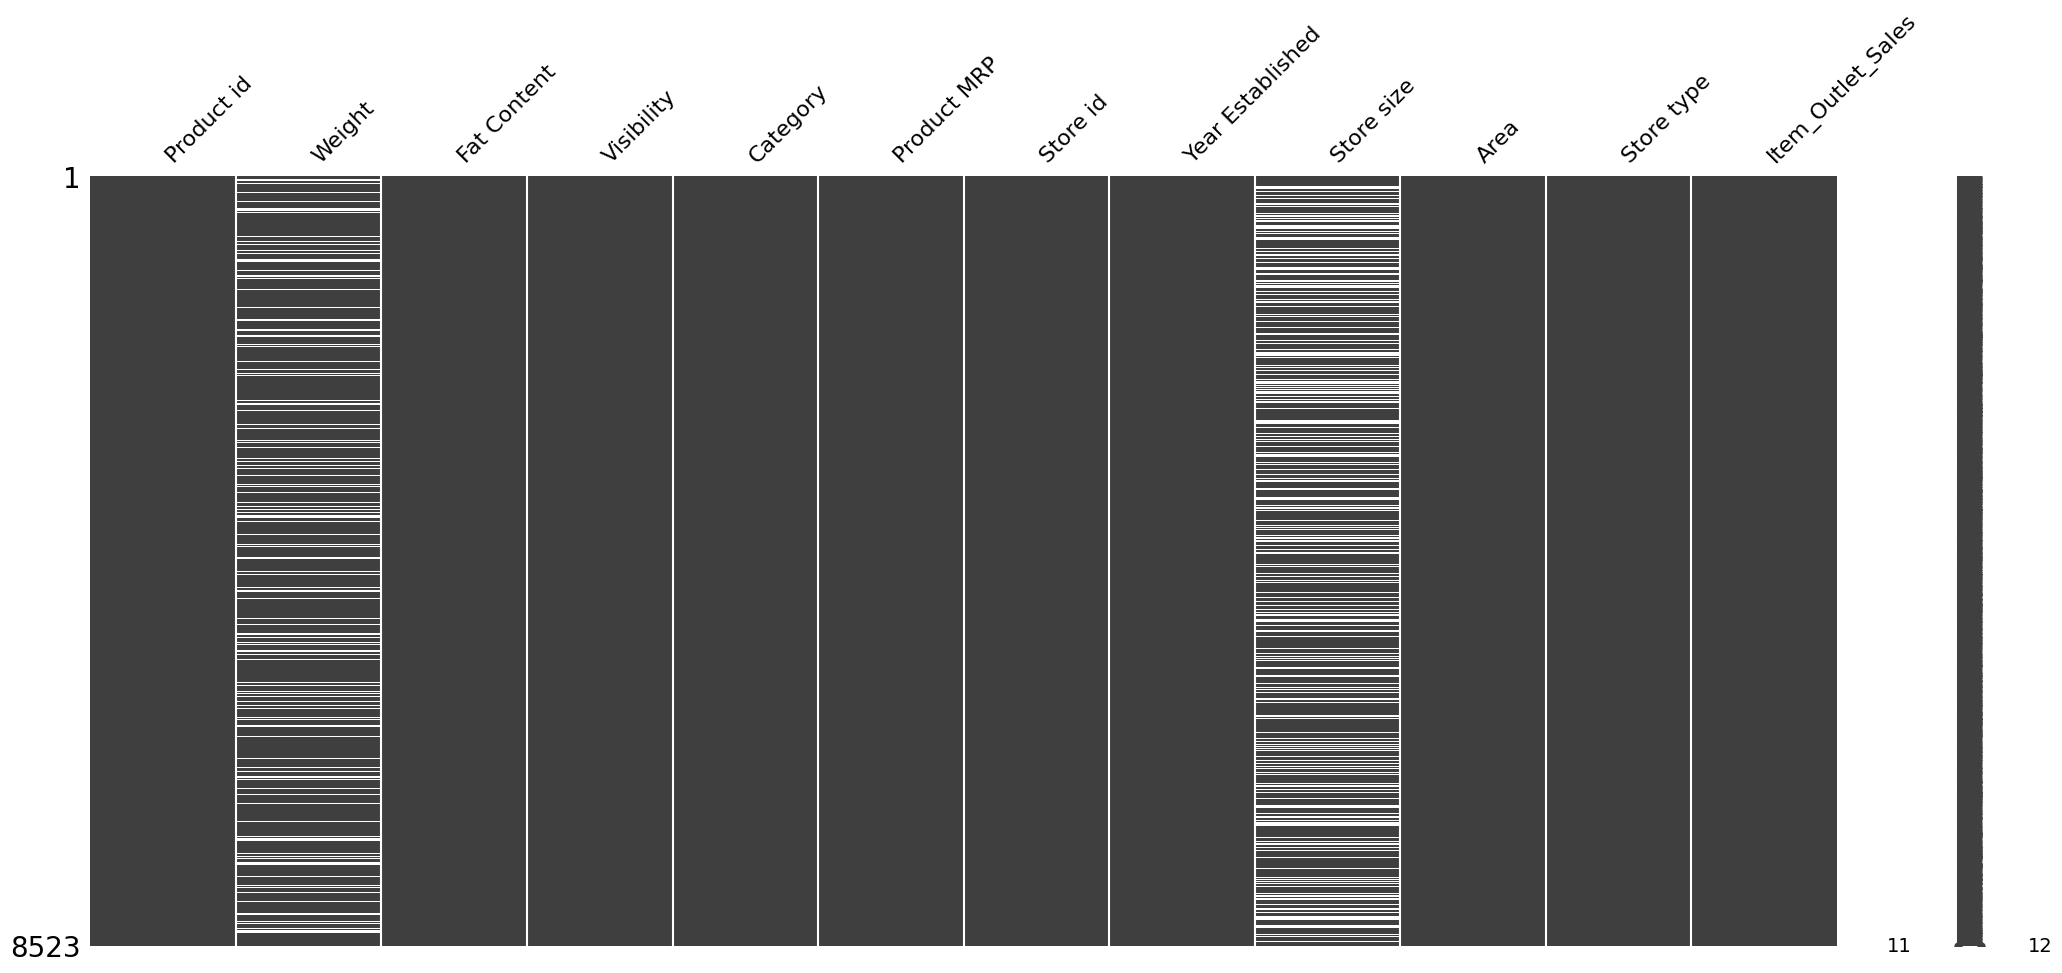

In [28]:
msno.matrix(df)

In [32]:
# View value counts for Store size
df['Store size'].value_counts()

,count
Store size,
Medium,2793
Small,2388
High,932


In [37]:
# filter categorical/string objects
cat_cols=df.select_dtypes('object').columns

# filter numbers
num_cols=df.select_dtypes('number').columns

In [41]:
# adress missing values in df (categorical/string) with placeholder MISSING
df[cat_cols]=df[cat_cols].fillna('MISSING')

# check for applied changes
df.isna().sum()

,0
Product id,0
Weight,1463
Fat Content,0
Visibility,0
Category,0
Product MRP,0
Store id,0
Year Established,0
Store size,0
Area,0


Before filling number columns with placeholder, check describe()

In [43]:
# check null nums
df[num_cols].isna().sum()

,0
Weight,1463
Visibility,0
Product MRP,0
Store id,0
Year Established,0
Item_Outlet_Sales,0


In [46]:
# summary of num cols
for col in num_cols:
  print(f'summary of {col}: ')
  print(df[col].describe())
  print("\n")

summary of Weight: 
count    7060.000000
mean       12.857645
std         4.643456
min         4.555000
25%         8.773750
50%        12.600000
75%        16.850000
max        21.350000
Name: Weight, dtype: float64


summary of Visibility: 
count    8523.000000
mean        0.066132
std         0.051598
min         0.000000
25%         0.026989
50%         0.053931
75%         0.094585
max         0.328391
Name: Visibility, dtype: float64


summary of Product MRP: 
count    8523.000000
mean      140.992782
std        62.275067
min        31.290000
25%        93.826500
50%       143.012800
75%       185.643700
max       266.888400
Name: Product MRP, dtype: float64


summary of Store id: 
count    8523.000000
mean       29.108765
std        13.927648
min        10.000000
25%        17.000000
50%        27.000000
75%        45.000000
max        49.000000
Name: Store id, dtype: float64


summary of Year Established: 
count    8523.000000
mean     1997.831867
std         8.371760
min      

nothing needs to be addressed, so we fill all null values in num_cols with -1 placeholder:

In [49]:
# fill null values with -1 placeholder
df[num_cols]=df[num_cols].fillna(-1)

# check applied changes
df[num_cols].isna().sum()

,0
Weight,0
Visibility,0
Product MRP,0
Store id,0
Year Established,0
Item_Outlet_Sales,0


### Consistent Values

Check each string column's value counts for inconsistent values:


In [51]:
# loop through each categorical/string column
for col in cat_cols:
  print(f'value counts of {col}: ')
  print(df[col].value_counts())
  print("\n")

value counts of Product id: 
Product id
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


value counts of Fat Content: 
Fat Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


value counts of Category: 
Category
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


value counts of Store size: 
Store size
Medium     2793
MISSING    2410
Small      2388
High

This column has incosistent values:
- Fat Content: LF, reg, low fat

In [52]:
# check for inconsistent values
df['Fat Content'].value_counts()

,count
Fat Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [54]:
# Replace LF, low fat with Low Fat, and req with Regular:
df['Fat Content']=df['Fat Content'].replace({'LF':'Low Fat',
                                             "low fat":'Low Fat',
                                             'reg':'Regular'})

# Confirm applied changes
df['Fat Content'].value_counts()

,count
Fat Content,
Low Fat,5517
Regular,3006


### Describe Numeric Data
- min, max, mean

In [56]:
# get numeric columns
num_cols=df.select_dtypes('number').columns

# use the describe method and filter using .loc()
df[num_cols].describe().loc[['min','max','mean']]

,Weight,Visibility,Product MRP,Store id,Year Established,Item_Outlet_Sales
min,-1.000000,0.000000,31.290000,10.000000,1985.000000,33.290000
max,21.350000,0.328391,266.888400,49.000000,2009.000000,13086.964800
mean,10.478936,0.066132,140.992782,29.108765,1997.831867,2181.288914


## Feature Inspection